In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [3]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [4]:
question = 'what is the latest information?'

answer = ask_api(client, question)
len(answer)

10000

In [5]:
answer[0]

{'claim': 'Event for the Chronically Chill meetup group',
 'url': 'https://www.meetup.com/the-chronically-chill-meetup-group/events/313526040/',
 'domain': 'meetup.com',
 'url_domain': 'meetup.com',
 'date_added': '2026-03-14 22:28:38'}

In [6]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)
df.head()

# ran at 15:13pm -> see date_added 15:12:52pm

,claim,url,domain,url_domain,date_added
0,Event for the Chronically Chill meetup group,https://www.meetup.com/the-chronically-chill-m...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00
2,Event for an international arthouse movie meet...,https://www.meetup.com/boston-international-ar...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00
1,Event for a gaming meetup organized by Soba Ga...,https://www.meetup.com/soba-gaming/events/3131...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00
3,A 23-year-old man has killed his mother and ha...,https://www.hindustantimes.com/cities/noida-ne...,hindustantimes.com,hindustantimes.com,2026-03-14 15:28:13-07:00
5,"Seven individuals, including two minors, have ...",https://www.hindustantimes.com/cities/noida-ne...,hindustantimes.com,hindustantimes.com,2026-03-14 15:28:13-07:00


In [7]:
df.shape

(10000, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [8]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [10]:
df.head()

,claim,url,domain,url_domain,date_added
0,Event for the Chronically Chill meetup group,https://www.meetup.com/the-chronically-chill-m...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00
2,Event for an international arthouse movie meet...,https://www.meetup.com/boston-international-ar...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00
1,Event for a gaming meetup organized by Soba Ga...,https://www.meetup.com/soba-gaming/events/3131...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00
3,A 23-year-old man has killed his mother and ha...,https://www.hindustantimes.com/cities/noida-ne...,hindustantimes.com,hindustantimes.com,2026-03-14 15:28:13-07:00
5,"Seven individuals, including two minors, have ...",https://www.hindustantimes.com/cities/noida-ne...,hindustantimes.com,hindustantimes.com,2026-03-14 15:28:13-07:00


In [11]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.7)
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,Event for the Chronically Chill meetup group,https://www.meetup.com/the-chronically-chill-m...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00,0
2,Event for an international arthouse movie meet...,https://www.meetup.com/boston-international-ar...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00,1
1,Event for a gaming meetup organized by Soba Ga...,https://www.meetup.com/soba-gaming/events/3131...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00,2
3,A 23-year-old man has killed his mother and ha...,https://www.hindustantimes.com/cities/noida-ne...,hindustantimes.com,hindustantimes.com,2026-03-14 15:28:13-07:00,3
5,"Seven individuals, including two minors, have ...",https://www.hindustantimes.com/cities/noida-ne...,hindustantimes.com,hindustantimes.com,2026-03-14 15:28:13-07:00,4


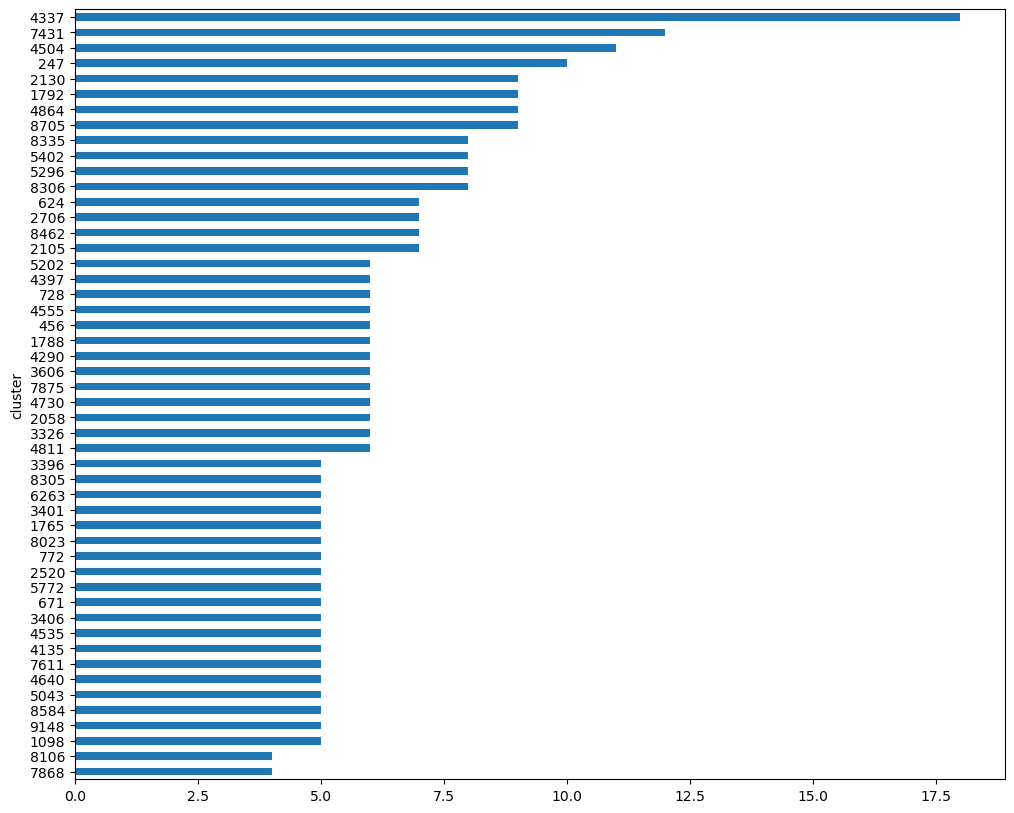

In [12]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [13]:
top_clusters = df['cluster'].value_counts()[0:20].index.values
top_clusters

array([4337, 7431, 4504,  247, 2130, 1792, 4864, 8705, 8335, 5402, 5296,
       8306,  624, 2706, 8462, 2105, 5202, 4397,  728, 4555], dtype=int64)

In [14]:
cluster = top_clusters[0]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Event at Denver Library', 'Another event at the Denver Library',
       'An event at the Denver Library', 'Event at Denver Library',
       'Event at Denver Library', 'Event at Denver Library',
       'Event at Denver Library',
       'Information about a specific event at the Denver Library',
       'Information about another specific event at the Denver Library',
       'Event scheduled at Denver Library',
       'Event scheduled at Denver Library',
       'Event scheduled at Denver Library',
       'Another event at Denver Library', 'Event at Denver Library',
       'An event is scheduled at the Denver Library.',
       'An event is scheduled at the Denver Library.',
       'An event is scheduled at the Denver Library.',
       'An event is scheduled at the Denver Library.'], dtype=object)

In [15]:
cluster = top_clusters[1]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.'],
      dtype=object)

In [16]:
cluster = top_clusters[2]

df[df['cluster']==cluster].head(20)['claim'].values

array(['An article discusses the conditions in immigration detention facilities.',
       'The article discusses the conditions of immigration detention.',
       'Report on the conditions of immigration detention facilities.',
       'The article discusses the conditions of immigration detention facilities.',
       'The article discusses the conditions of immigration detention.',
       'The article discusses the conditions of immigration detention facilities.',
       'Discussing the conditions of immigration detention',
       'The article discusses conditions in immigration detention facilities.',
       'claims about the conditions in immigration detention facilities',
       'The article discusses the conditions of immigration detention facilities.',
       'Discusses the conditions of immigration detention facilities.'],
      dtype=object)

In [17]:
cluster = top_clusters[3]

df[df['cluster']==cluster].head(20)['claim'].values

array(['News article', 'News article', 'News article', 'News article',
       'News article', 'News article', 'News article', 'News article',
       'News article', 'News article'], dtype=object)

In [18]:
cluster = top_clusters[4]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Claim related to a news article',
       'Claim related to a news article',
       'Claim related to a news article',
       'Claim related to a news article',
       'Claim related to news article cm246kdxjr7o',
       'Claim related to news article cvg1ye879r1o',
       'Claim related to news article c1w558gvrdro',
       'Claim related to news article clygqnlpwero',
       'Claim related to news article c309478l04go'], dtype=object)

In [19]:
cluster = top_clusters[5]

df[df['cluster']==cluster].head(20)['claim'].values

array(['A news article related to a specific topic or event.',
       'News article related to a specific topic or event',
       'News article related to a specific topic or event',
       'News article related to a specific topic or event',
       'A news article related to a specific topic or event.',
       'A news article related to a specific topic or event.',
       'A news update related to a specific topic or event.',
       'A news update related to a specific topic or event.',
       'A news update related to a specific topic or event.'],
      dtype=object)

In [20]:
cluster = top_clusters[6]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL'],
      dtype=object)

In [21]:
cluster = top_clusters[7]

df[df['cluster']==cluster].head(20)['claim'].values

array(['No specific claim discernible', 'No specific claim discernible',
       'No specific claim discernible', 'No specific claim discernible',
       'No specific claim discernible', 'No specific claim discernible',
       'No specific claim discernible', 'No specific claim discernible',
       'No specific claim discernible'], dtype=object)

In [22]:
cluster = top_clusters[8]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Live updates on a synagogue shooting in Michigan.',
       'Live updates on the Michigan synagogue shooting coverage.',
       'Live updates on the Michigan synagogue shooting',
       'Live updates on the Michigan synagogue shooting.',
       'Live updates on the Michigan synagogue shooting.',
       'Live updates on the Michigan synagogue shooting.',
       'Live updates on the Michigan synagogue shooting.',
       'Live updates on the Michigan synagogue shooting.'], dtype=object)

In [23]:
cluster = top_clusters[9]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Details related to a specific news post.',
       'Details related to a specific news post.',
       'Details related to a specific news post.',
       'Details related to a specific news post.',
       'Details related to a specific news post.',
       'Details related to a specific news post.',
       'Details related to a specific news post.',
       'Details related to a specific news post.'], dtype=object)

In [24]:
cluster = top_clusters[10]

df[df['cluster']==cluster].head(20)['claim'].values

array(['News update or article', 'News update or article',
       'News update or article', 'News update or article',
       'News update or article', 'News update or article',
       'News update or article', 'News update or article'], dtype=object)

# Find a Cluster

Sometimes you will know what you are looking for but not know what cluster it exists in. This will help you find it.

In [25]:
search_term = 'arrest'

df[df['claim'].str.contains(search_term)]

,claim,url,domain,url_domain,date_added,cluster
5,"Seven individuals, including two minors, have ...",https://www.hindustantimes.com/cities/noida-ne...,hindustantimes.com,hindustantimes.com,2026-03-14 15:28:13-07:00,4
60,A woman has been arrested following an 18-day ...,https://www.dailyrecord.co.uk/news/uk-world-ne...,dailyrecord.co.uk,dailyrecord.co.uk,2026-03-14 15:00:55-07:00,60
101,Police have arrested two men in Buffalo.,https://yahoo.com/news/news/articles/buffalo-p...,yahoo.com/news,yahoo.com/news,2026-03-14 14:41:47-07:00,97
97,A man has been arrested following an argument ...,https://yahoo.com/news/news/articles/man-arres...,yahoo.com/news,yahoo.com/news,2026-03-14 14:41:47-07:00,100
110,A teen has been accused of fatally shooting th...,https://news3lv.com/news/nation-world/teen-acc...,news3lv.com,news3lv.com,2026-03-14 14:37:17-07:00,109
...,...,...,...,...,...,...
9841,A Bandon man has been arrested following an al...,https://kezi.com/news/local/bandon-man-arreste...,kezi.com,kezi.com,2026-03-12 12:01:08-07:00,9044
9854,Two men have been arrested for allegedly imper...,https://kesq.com/news/crime/2026/03/12/two-men...,kesq.com,kesq.com,2026-03-12 11:58:54-07:00,8952
9864,Detectives made an arrest in a decades-old hom...,https://kutv.com/news/local/detectives-make-ar...,kutv.com,kutv.com,2026-03-12 11:56:40-07:00,9065
9869,Gulf Shores police issued a spring break warni...,https://www.al.com/news/2026/03/gulf-shores-po...,al.com,al.com,2026-03-12 11:55:29-07:00,9073


In [26]:
top_clusters = df[df['claim'].str.contains(search_term)]['cluster'].value_counts()[0:10].index.values

In [27]:
cluster = top_clusters[0]

df[df['cluster']==cluster].head(20)

,claim,url,domain,url_domain,date_added,cluster
2878,Parents of two girls who died in a mobile home...,https://www.sgvtribune.com/2026/03/13/parents-...,sgvtribune.com,sgvtribune.com,2026-03-13 19:17:52-07:00,2706
2902,Parents of two girls who died in a fire are ar...,https://www.dailynews.com/2026/03/13/parents-o...,dailynews.com,dailynews.com,2026-03-13 19:12:42-07:00,2706
2907,Parents of two girls who died in a mobile home...,https://www.dailybreeze.com/2026/03/13/parents...,dailybreeze.com,dailybreeze.com,2026-03-13 19:09:30-07:00,2706
2914,Parents of two girls who died in a fire have b...,https://www.ocregister.com/2026/03/13/parents-...,ocregister.com,ocregister.com,2026-03-13 19:07:29-07:00,2706
2919,Parents of two girls who died in a mobile home...,https://www.presstelegram.com/2026/03/13/paren...,presstelegram.com,presstelegram.com,2026-03-13 19:05:33-07:00,2706
2933,Parents of two girls who died in fire are arre...,https://www.pressenterprise.com/2026/03/13/par...,pressenterprise.com,pressenterprise.com,2026-03-13 19:00:57-07:00,2706
2934,Parents of two girls who died in a mobile home...,https://www.pasadenastarnews.com/2026/03/13/pa...,pasadenastarnews.com,pasadenastarnews.com,2026-03-13 18:59:43-07:00,2706


In [28]:
cluster = top_clusters[1]

df[df['cluster']==cluster].head(20)

,claim,url,domain,url_domain,date_added,cluster
6445,A pedophile catcher is making many arrests in ...,https://www.themorningsun.com/2026/03/13/a-ped...,themorningsun.com,themorningsun.com,2026-03-13 04:04:16-07:00,5956
6467,A pedophile catcher is making numerous arrests...,https://www.macombdaily.com/2026/03/13/a-pedop...,macombdaily.com,macombdaily.com,2026-03-13 03:52:46-07:00,5956
6500,A pedophile catcher is making numerous arrests...,https://www.theoaklandpress.com/2026/03/13/a-p...,theoaklandpress.com,theoaklandpress.com,2026-03-13 03:47:31-07:00,5956


In [29]:
cluster = top_clusters[2]

df[df['cluster']==cluster].head(20)

,claim,url,domain,url_domain,date_added,cluster
445,Report on arrests in the Mid-Hudson Valley,https://www.dailyfreeman.com/2026/03/14/mid-hu...,dailyfreeman.com,dailyfreeman.com,2026-03-14 12:56:57-07:00,426
4817,Report on arrests in the Mid Hudson Valley for...,https://www.dailyfreeman.com/2026/03/13/mid-hu...,dailyfreeman.com,dailyfreeman.com,2026-03-13 11:29:11-07:00,426
9426,Report on arrests in the Mid Hudson Valley for...,https://www.dailyfreeman.com/2026/03/12/mid-hu...,dailyfreeman.com,dailyfreeman.com,2026-03-12 13:15:02-07:00,426


In [30]:
cluster = top_clusters[3]

df[df['cluster']==cluster].head(20)

,claim,url,domain,url_domain,date_added,cluster
2629,An Evansville man was arrested for drunk drivi...,https://14news.com/video/2026/03/14/evansville...,14news.com,14news.com,2026-03-13 20:34:17-07:00,2473
2869,An Evansville man was arrested for drunk drivi...,https://14news.com/2026/03/14/evansville-man-a...,14news.com,14news.com,2026-03-13 19:19:31-07:00,2473


# Graph Analysis

Every answer is a graph edgelist. Every row is a graph link.

In [31]:
df.head(1)

,claim,url,domain,url_domain,date_added,cluster
0,Event for the Chronically Chill meetup group,https://www.meetup.com/the-chronically-chill-m...,meetup.com,meetup.com,2026-03-14 15:28:38-07:00,0


Edge: domain -> url_domain

Claim: what was claimed to have happened

url_domain: the source website

domain: the amplifiying website (usually the same as source, but very interesting when not! maps the internet)

date_added: when we saw the claim on the internet, UTC time.

In [32]:
import networkx as nx

In [33]:
G = nx.from_pandas_edgelist(df, source='domain', target='url_domain')
print(G)

Graph with 1346 nodes and 1447 edges


I have made this extremely easy for Data Scientists. Use the API, get data back. Load it into a DataFrame. Use it.

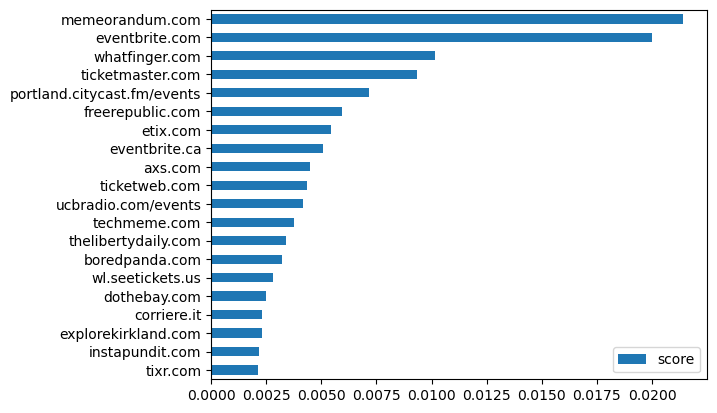

In [34]:
scores = nx.pagerank(G)
score_df = pd.DataFrame([scores]).T
score_df.columns = ['score']
score_df.sort_values('score', ascending=False, inplace=True)
score_df[0:20].plot.barh().invert_yaxis()

In [35]:
# for visualization
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix

def draw_graph(G, show_names=False, node_size=3, font_size=10, edge_width=0.5):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency)
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores = scores, edge_width=edge_width)
    
    return SVG(image)

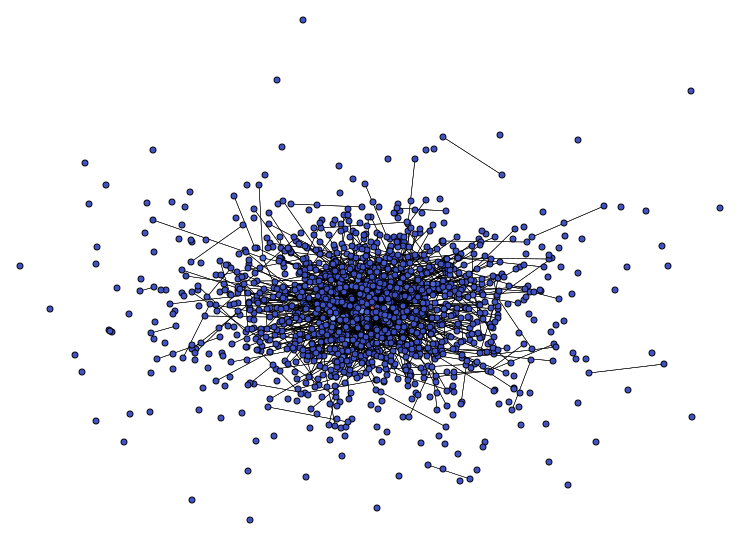

In [36]:
draw_graph(G)

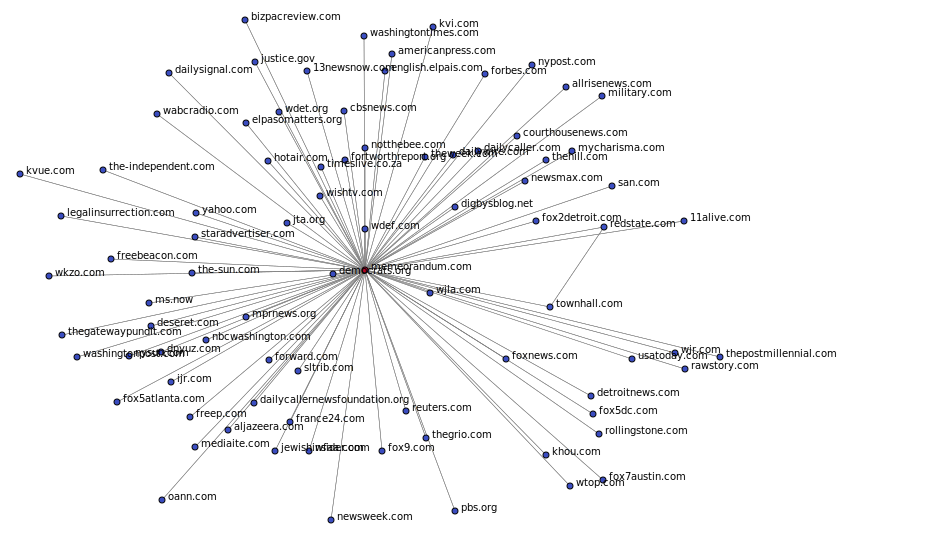

In [37]:
ego = 'memeorandum.com'

G_check = nx.ego_graph(G, ego)

draw_graph(G_check, show_names=True)

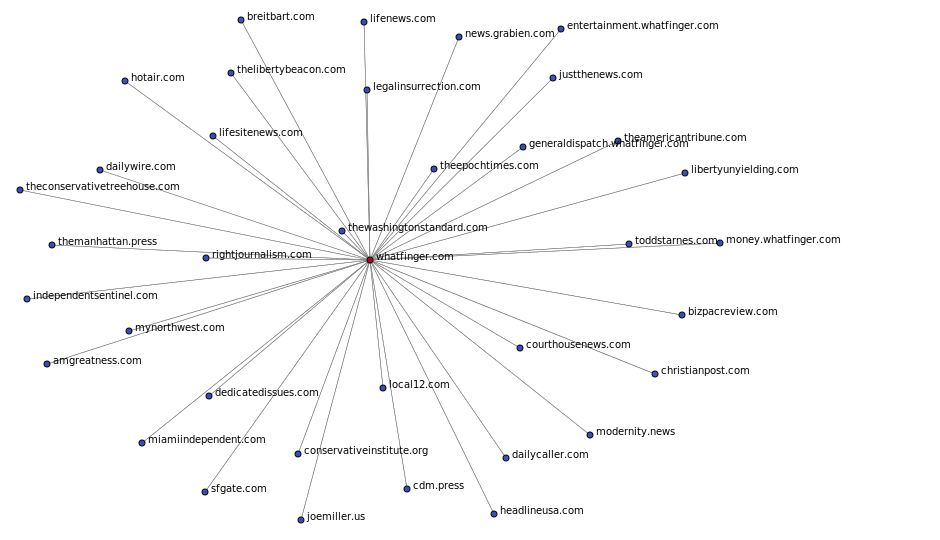

In [38]:
ego = 'whatfinger.com'

G_check = nx.ego_graph(G, ego)

draw_graph(G_check, show_names=True)

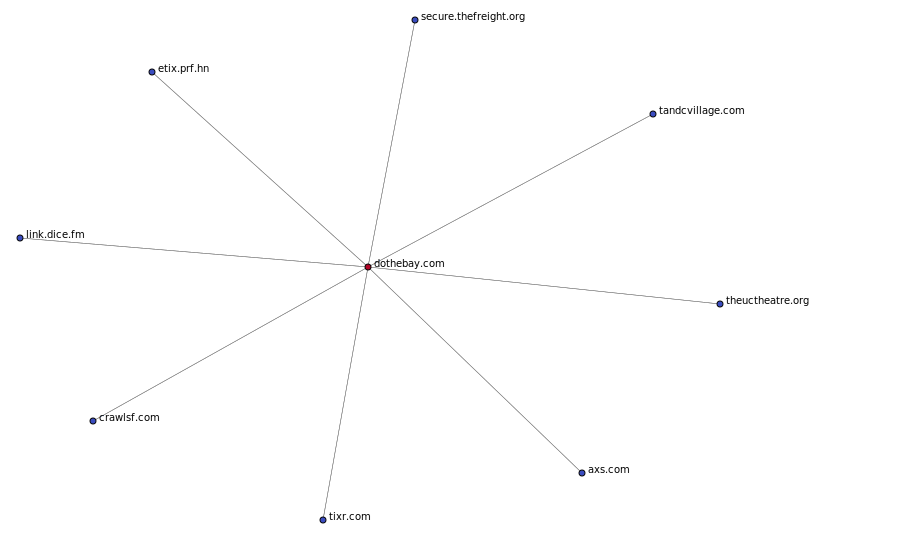

In [39]:
ego = 'dothebay.com'

G_check = nx.ego_graph(G, ego)

draw_graph(G_check, show_names=True)